## Model 1: Plain RNN (shared weights, no encoder/decoder split, no attention)


In [2]:

import sys, os
sys.path.append(os.path.abspath('../src'))

from data_prep import load_split_data, device, MAX_LENGTH, SOS_token, EOS_token, PAD_token, UNK_token, RANDOM_STATE
from train_utils import train, plot_losses, evaluateRandomly, compute_bleu, save_result, count_parameters, timeSince,perplexity, measure_inference_latency

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import time

print(f"device = {device} | random_state = {RANDOM_STATE}")

device = cpu | random_state = 20


In [4]:
# single call gets vocab, 80/10/10 split, and DataLoaders in data_prep.py
data = load_split_data(batch_size=64)
input_lang, output_lang = data["input_lang"], data["output_lang"]
train_pairs, val_pairs, test_pairs = data["train_pairs"], data["val_pairs"], data["test_pairs"]
train_loader, val_loader = data["train_loader"], data["val_loader"]

Read 331266 sentence pairs
Trimmed to 271824 pairs (< 10 tokens/sentence)
Sampled subset (random_state=20): 8000 pairs
Vocab sizes -> deu: 5743 words | eng: 4028 words
Train: 6400 | Val: 800 | Test: 800


In [5]:
class PlainRNNSeq2Seq(nn.Module):
    """One shared nn.RNN used both to read the source sentence and to
    generate the target sentence (no separate encoder/decoder weights)."""

    def __init__(self, input_size, output_size, hidden_size, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size

        # separate embedding tables (source/target vocabs differ), padding_idx=PAD
        # so the PAD token's embedding stays fixed at zero and isn't learned
        self.src_embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.tgt_embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)

        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)   # shared recurrent core
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def encode(self, input_tensor):
        embedded = self.dropout(self.src_embedding(input_tensor))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        hidden = encoder_hidden
        outputs = []

        for i in range(MAX_LENGTH):
            embedded = F.relu(self.tgt_embedding(decoder_input))
            out, hidden = self.rnn(embedded, hidden)   # SAME rnn weights as encode()
            logits = self.out(out)
            outputs.append(logits)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)   # teacher forcing
            else:
                _, topi = logits.topk(1)
                decoder_input = topi.squeeze(-1).detach()          # greedy decoding

        outputs = torch.cat(outputs, dim=1)
        return F.log_softmax(outputs, dim=-1), hidden, None


class EncoderWrapper(nn.Module):
    """Thin wrapper so train_utils' shared train()/evaluate() helpers
    (written for encoder(x) -> outputs, hidden) work unchanged."""
    def __init__(self, model): super().__init__(); self.model = model
    def forward(self, x): return self.model.encode(x)
    def train(self, mode=True): self.model.train(mode); return self
    def eval(self): self.model.eval(); return self
    def parameters(self): return []   # no separate params -- optimizer is built on `model` directly


class DecoderWrapper(nn.Module):
    def __init__(self, model): super().__init__(); self.model = model
    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        return self.model(encoder_outputs, encoder_hidden, target_tensor)

In [6]:
hidden_size = 128
EPOCHS = 40

model = PlainRNNSeq2Seq(input_lang.n_words, output_lang.n_words, hidden_size).to(device)
encoder = EncoderWrapper(model).to(device)
decoder = DecoderWrapper(model).to(device)

n_params = count_parameters(model)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 1,803,324


In [7]:
# custom training loop (can't reuse train_utils.train() directly since encoder/decoder
# share one optimizer here, unlike the other 3 which have 2 separate networks)
start = time.time()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.NLLLoss(ignore_index=PAD_token)   # PAD positions don't count toward loss

train_losses, val_losses = [], []
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for input_tensor, target_tensor in train_loader:
        optimizer.zero_grad()
        encoder_outputs, encoder_hidden = model.encode(input_tensor)
        decoder_outputs, _, _ = model(encoder_outputs, encoder_hidden, target_tensor)
        loss = criterion(decoder_outputs.view(-1, decoder_outputs.size(-1)), target_tensor.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    tr_loss = total_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        total_val = 0
        for input_tensor, target_tensor in val_loader:
            encoder_outputs, encoder_hidden = model.encode(input_tensor)
            decoder_outputs, _, _ = model(encoder_outputs, encoder_hidden, target_tensor)
            loss = criterion(decoder_outputs.view(-1, decoder_outputs.size(-1)), target_tensor.view(-1))
            total_val += loss.item()
        va_loss = total_val / len(val_loader)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    if epoch % 5 == 0 or epoch == 1:
        print('%s (epoch %d/%d) train_loss=%.4f val_loss=%.4f' %
              (timeSince(start, epoch / EPOCHS), epoch, EPOCHS, tr_loss, va_loss))

0m 3s (- 2m 19s) (epoch 1/40) train_loss=5.8413 val_loss=5.1784
0m 18s (- 2m 11s) (epoch 5/40) train_loss=4.0867 val_loss=4.2273
0m 29s (- 1m 28s) (epoch 10/40) train_loss=3.3777 val_loss=3.9625
0m 41s (- 1m 9s) (epoch 15/40) train_loss=2.9436 val_loss=3.9037
0m 53s (- 0m 53s) (epoch 20/40) train_loss=2.6209 val_loss=3.9198
1m 11s (- 0m 42s) (epoch 25/40) train_loss=2.3558 val_loss=3.9684
1m 24s (- 0m 28s) (epoch 30/40) train_loss=2.1446 val_loss=4.0278
1m 36s (- 0m 13s) (epoch 35/40) train_loss=1.9591 val_loss=4.1061
1m 49s (- 0m 0s) (epoch 40/40) train_loss=1.8134 val_loss=4.1987


#### Loss Curve

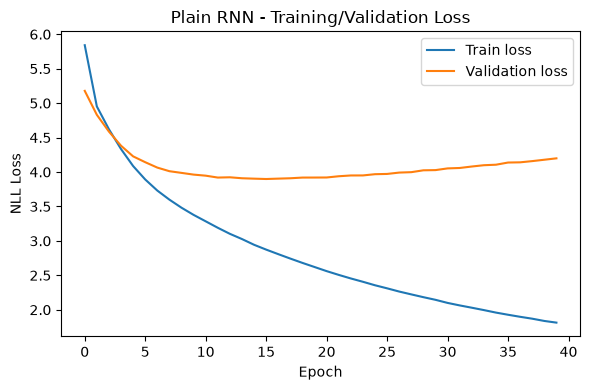

In [8]:
plot_losses(train_losses, val_losses, "Plain RNN - Training/Validation Loss",
            save_path="../outputs/figures/01_rnn_loss.png")

In [9]:
# qualitative check: 10 held-out TEST sentences (never trained on), seeded so the
# same 10 examples print every run (random_state=20)
evaluateRandomly(encoder, decoder, test_pairs, input_lang, output_lang, n=10, seed=RANDOM_STATE)

> was ist heutzutage nur mit den kindern los ?
= what s going on with children these days ?
< how many apples is it ?

> ist das wirklich alles ?
= is that really all ?
< what are you going to do that ?

> hast du pfannkuchen gegessen ?
= did you have pancakes ?
< i wonder if you ve done that

> ich akzeptiere deine bedingungen
= i accept your terms
< i m not wholly convinced that you re

> er ist hier gestern heil angekommen
= he arrived here safely yesterday
< he is the tallest of the kidnappers in custody

> viele sind skeptisch
= many people are skeptical
< you re lucky that you re a book to me

> legen sie ihm handschellen an
= cuff him
< let s not get hysterical for me

> tom zog die vorhange zu ehe er sich entkleidete
= tom closed the curtains before he got undressed
< tom has a lot of creative ideas

> ich wei noch wie wutend du mich gemacht hast
= i remember how angry you made me
< i m not going to get some more here

> dieses pedal ist schwergangig
= this pedal is stiff
< you

#### Evaluation Metrices: Bleu-4, Perplexity, Inference Latency

In [10]:
bleu = compute_bleu(encoder, decoder, test_pairs, input_lang, output_lang)
print(f"Corpus BLEU-4 (test set, n={len(test_pairs)}): {bleu:.4f}")

Corpus BLEU-4 (test set, n=800): 0.0100


In [11]:

train_ppl = perplexity(train_losses[-1])
val_ppl = perplexity(val_losses[-1])
best_val_ppl = perplexity(min(val_losses))
print(f"Perplexity -> train: {train_ppl:.2f} | val: {val_ppl:.2f} | best val: {best_val_ppl:.2f}")

avg_latency_ms, throughput = measure_inference_latency(encoder, decoder, test_pairs, input_lang, output_lang, n=100)
print(f"Inference latency: {avg_latency_ms:.2f} ms/sentence | Throughput: {throughput:.1f} sentences/sec")

Perplexity -> train: 6.13 | val: 66.60 | best val: 49.33
Inference latency: 1.58 ms/sentence | Throughput: 634.3 sentences/sec


In [12]:
save_result("01_RNN", {
    "architecture": "Plain shared-weight RNN (no encoder/decoder split, no attention)",
    "hidden_size": hidden_size, "batch_size": 64, "epochs": EPOCHS,
    "trainable_params": n_params,
    "final_train_loss": train_losses[-1], "final_val_loss": val_losses[-1],
    "train_losses": train_losses, "val_losses": val_losses,
    "test_bleu": bleu, "test_set_size": len(test_pairs),
    "train_perplexity": train_ppl,
    "val_perplexity": val_ppl,
    "best_val_perplexity": best_val_ppl,
    "avg_inference_latency_ms": avg_latency_ms,
    "inference_throughput_sentences_per_sec": throughput
})

Saved results for '01_RNN' -> d:\NMT_F\nmt-comparison\src\..\outputs\results.json


### Discussion & Conclusion

The plain RNN (single shared nn.RNN, with no encoder/decoder split and no attention) was trained for 40 epochs. The training loss decreased steadily from 5.84 at epoch 1 to 1.81 at epoch 40, showing that the model continued learning the training data. However, the validation loss decreased from 5.18 to approximately 3.90 by epoch 15, after which it gradually increased, reaching 4.20 at epoch 40. This indicates that the model began to overfit after around epoch 10, as its performance on unseen validation data stopped improving while training performance continued to improve.

The relatively high validation loss and low Corpus BLEU-4 score of 0.0100 on the held-out test set indicate that the model has limited translation quality. Qualitatively, translations are grammatically plausible English sentences but they are often unrelated to the meaning of the source sentence. For example, "cuff him" was translated as "let s not get hysterical for me", demonstrating that the model struggles to preserve the source sentence's semantic meaning.

This matches the architecture's core limitation that, with only one shared hidden state carrying all information from source to target, and no attention or dedicated decoder network, the model struggles to reliably tie specific generated words back to specific source words. 

